# **Bioreact**: Bioreactor Modelling and Computer Simulation (2022)

Autores: Emiliano Balderas Ramírez, Octavio Tonatiuh Ramírez Reivich

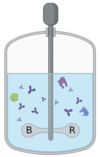

# **Código preparativo**

Importar módulos y definir funciones

In [29]:
#Importar modulos
import sympy as sym
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sym
import altair as alt
import pandas as pd

#definir variables de sympy
T, X, S, y, h = sym.symbols('T X S y h')
μmax, Ks, V, F = sym.symbols('μmax Ks V F')
Sr, I, Ki, D, Kc= sym.symbols('Sr I Ki D Kc')
Srs, Ss, Xs, Ds, Tau= sym.symbols('Srs Ss Xs Ds Tau')
λ = sym.symbols('λ')

**Funciones**

Función Análisis

In [30]:
#Función para parte analítica

def Analisis_Bioreact(f1, f2, constantes, Numero_de_estados_estacionarios=1):
    
  '''''''''''
  ESTADO ESTACIONARIO 1

  '''''''''''  
  
  if Numero_de_estados_estacionarios>=1 :
    print('---------------------------------------------------------------')
    print('\033[1m ESTADO ESTACIONARIO 1 \033[0m')
    print('\nLos valores de X y S en el estado estacionario 1 son:')

    # Obtener Ŝ1:     Para encontrar valor de concentración de sustrato en estado estacionario 1 (Ŝ1), igualamos f1 a 0 y despejamos para S:
    Ss1 = sym.solve(f1, S)[0]
    #display(Ss1)
    Ŝ = Ss1.evalf(subs=constantes)
    print('\033[1m Ŝ1 \033[0m = ', Ŝ)
    constantes[S] = Ŝ
    Ŝ_1= Ŝ

    #Obtener X̂:       Para encontrar valor de concentración de biomasa en estado estacionario 1(X̂1), igualamos f2 a 0 y despejamos para X \nusamos el valor de Ŝ1 obtenido en la ecuación anterior para encontrar X̂1
    Xs1 = sym.solve(f2, X)[0]
    #display(Xs1)
    X̂ = Xs1.evalf(subs=constantes)
    print('\033[1m X̂1 \033[0m =  ', X̂)
    constantes[X] = X̂
    X̂_1=X̂

    #MATRIZ JACOBIANA
    print('\nLos coeficientes de la matriz Jacobiana (J) son:')
    #Coeficiente a11 (Derivada parcial de f1 respecto a X)
    a11_1 = sym.diff(f1, X)
    valor_a11_1= a11_1.evalf(subs=constantes)
    print('\033[1m a11 \033[0m=', valor_a11_1)

    #Coeficiente a12 (Derivada parcial de f1 respecto a S)
    a12_1 = sym.diff(f1, S)
    valor_a12_1 = a12_1.evalf(subs=constantes)
    print('\033[1m a12 \033[0m=', valor_a12_1)

    #Coeficiente a21(Derivada parcial de f2 respecto a X)
    a21_1 = sym.diff(f2, X)
    valor_a21_1= a21_1.evalf(subs=constantes)
    print('\033[1m a21 \033[0m=', valor_a21_1)

    #Coeficiente a22 (Derivada parcial de f2 respecto a S)
    a22_1 = sym.diff(f2, S)
    valor_a22_1= a22_1.evalf(subs=constantes)
    print('\033[1m a22 \033[0m=', valor_a22_1)

    #Matriz Jacobiana (J)
    J_1 = sym.Matrix([[valor_a11_1, valor_a12_1], [valor_a21_1, valor_a22_1]])
    print('\nLa matriz Jacobiana es (J):')
    display(J_1)


    #Eigenvalores
    print('\nLos eigenvalores (λ1 y λ2) son:')
    J_eigenvalues_1 = list(J_1.eigenvals().keys())
    λ1_1 = J_eigenvalues_1[0]
    λ2_1 = J_eigenvalues_1[1]
    print('\033[1m λ1 :\033[0m', λ1_1, '\n\033[1m λ2 :\033[0m', λ2_1)


    #Eigenvectores
    print('\nLos eigenvectores son:')
    J_eigenvect_1 = list(J_1.eigenvals().items())
    eigenvect_1_1 = J_eigenvect_1[0]
    eigenvect_2_1 = J_eigenvect_1[1]
    print('Eigenvector 1: ', eigenvect_1_1, '\nEigenvector 2: ',eigenvect_2_1)


    # Determinar estabilidad del sistema:
    print('\nSegún el Teorema de estabilidad de Lyapunov para ecuaciones diferenciales ordinarias no lineales:')
    if λ1_1 < 0 and λ2_1 < 0:  
      print("Los valores de λ indican un estado estacionario 1: \033[1m ESTABLE \033[0m")
      estabilidad_estado_1= 'Estable' 
    else:
      print("Los valores de λ indican un estado estacionario 1:\033[1m INESTABLE \033[0m")
      estabilidad_estado_1= 'Inestable' 
        
    '''
    df de  ESTADO ESTACIONARIO 1 Y EIGENVECTORES
    '''
    #DF de estado estacionario 1    
    df_estado_estacionario_1 = pd.DataFrame( { 'X' : [  float(X̂_1)  ] ,  'S' : [ float(Ŝ_1) ], 'Descripción' : ['Estado estacionario 1'] , 'Grupo' : ['Estado Estacionario'] }  )
    #DF de eigenvector 1 del estado estacionario 1
    df_eigenvector_1_estado_1 = pd.DataFrame( { 'X' : [ float(X̂_1) , float(X̂_1+eigenvect_1_1[0]) ] ,  'S' : [float(Ŝ_1), float(Ŝ_1+eigenvect_1_1[1]) ], 'Descripción' : ['Eigenvector 1 Estado 1', 'Eigenvector 1 Estado 1'] , 'Grupo' : ['Eigenvector', 'Eigenvector'] }  )
    #DF de eigenvector 2 del estado estacionario 1
    df_eigenvector_2_estado_1 = pd.DataFrame( { 'X' : [  float(X̂_1) , float(X̂_1+eigenvect_2_1[0]) ] ,  'S' : [float(Ŝ_1), float(Ŝ_1+eigenvect_2_1[1]) ], 'Descripción' : ['Eigenvector 2 Estado 1', 'Eigenvector 2 Estado 1'],  'Grupo' : ['Eigenvector', 'Eigenvector'] }  )
    #df de  ESTADO ESTACIONARIO 1 Y EIGENVECTORES
    df = pd.concat([df_estado_estacionario_1, df_eigenvector_1_estado_1, df_eigenvector_2_estado_1])
 

  ''''''''''
  ESTADO ESTACIONARIO 2
  '''''''''''
  if Numero_de_estados_estacionarios>=2:
    print('---------------------------------------------------------------')
    print('\033[1m ESTADO ESTACIONARIO 2 \033[0m')

    print('\nLos valores de X y S en el estado estacionario 2 son:')

    # Obtener Ŝ1:     Para encontrar valor de concentración de sustrato en estado estacionario 1 (Ŝ1), igualamos f1 a 0 y despejamos para S:
    Ss1 = sym.solve(f1, S)[1]
    #display(Ss1)
    Ŝ = Ss1.evalf(subs=constantes)
    print('\033[1m Ŝ1 \033[0m = ', Ŝ)
    constantes[S] = Ŝ
    Ŝ_2= Ŝ

    #Obtener X̂:       Para encontrar valor de concentración de biomasa en estado estacionario 1(X̂1), igualamos f2 a 0 y despejamos para X \nusamos el valor de Ŝ1 obtenido en la ecuación anterior para encontrar X̂1
    Xs1 = sym.solve(f2, X)[0]
    #display(Xs1)
    X̂ = Xs1.evalf(subs=constantes)
    print('\033[1m X̂1 \033[0m =  ', X̂)
    constantes[X] = X̂
    X̂_2=X̂

    #MATRIZ JACOBIANA
    print('\nLos coeficientes de la matriz Jacobiana (J) son:')
    #Coeficiente a11 (Derivada parcial de f1 respecto a X)
    a11_2 = sym.diff(f1, X)
    valor_a11_2= a11_2.evalf(subs=constantes)
    print('\033[1m a11 \033[0m=', valor_a11_2)

    #Coeficiente a12 (Derivada parcial de f1 respecto a S)
    a12_2 = sym.diff(f1, S)
    valor_a12_2= a12_2.evalf(subs=constantes)
    print('\033[1m a12 \033[0m=', valor_a12_2)

    #Coeficiente a21(Derivada parcial de f2 respecto a X)
    a21_2 = sym.diff(f2, X)
    valor_a21_2= a21_2.evalf(subs=constantes)
    print('\033[1m a21 \033[0m=', valor_a21_2)

    #Coeficiente a22 (Derivada parcial de f2 respecto a S)
    a22_2 = sym.diff(f2, S)
    valor_a22_2= a22_2.evalf(subs=constantes)
    print('\033[1m a22 \033[0m=', valor_a22_2)

    #Matriz Jacobiana (J)
    J_2 = sym.Matrix([[valor_a11_2, valor_a12_2], [valor_a21_2, valor_a22_2]])
    print('\nLa matriz Jacobiana es (J):')
    display(J_2)


    #Eigenvalores
    
    print('\nLos eigenvalores (λ1 y λ2) son:')
    J_eigenvalues_2 = list(J_2.eigenvals().keys())
    λ1_2 = J_eigenvalues_2[0]
    λ2_2 = J_eigenvalues_2[1]
    print('\033[1m λ1 :\033[0m', λ1_2, '\n\033[1m λ2 :\033[0m', λ2_2)


    #Eigenvectores
    print('\nLos eigenvectores son:')
    J_eigenvect_2 = list(J_2.eigenvals().items())
    eigenvect_1_2 = J_eigenvect_2[0]
    eigenvect_2_2 = J_eigenvect_2[1]
    print('Eigenvector 1: ',eigenvect_1_2, '\nEigenvector 2: ',eigenvect_2_2,)


    # Determinar estabilidad del sistema:
    print('\nSegún el Teorema de estabilidad de Lyapunov para ecuaciones diferenciales ordinarias no lineales:')
    if λ1_2 < 0 and λ2_2 < 0:  
      print("Los valores de λ indican un estado estacionario 2: \033[1m ESTABLE \033[0m")
      estabilidad_estado_2= 'Estable' 
    else:
      print("Los valores de λ indican un estado estacionario 2:\033[1m INESTABLE \033[0m")
      estabilidad_estado_2= 'Inestable' 


    print('---------------------------------------------------------------')

    '''
    df de ESTADO ESTACIONARIO 1 Y EIGENVECTORES + df de ESTADO ESTACIONARIO 2 Y EIGENVECTORES
    '''

    #DF de estado estacionario 2    
    df_estado_estacionario_2 = pd.DataFrame( { 'X' : [  float(X̂_2)  ] ,  'S' : [ float(Ŝ_2) ], 'Descripción' : ['Estado estacionario 2'],  'Grupo' : ['Estado Estacionario'] }  )
    #DF de eigenvector 1 del estado estacionario 2
    df_eigenvector_1_estado_2 = pd.DataFrame( { 'X' : [  float(X̂_2) , float(X̂_2+eigenvect_1_2[0]) ] ,  'S' : [float(Ŝ_2), float(Ŝ_2+eigenvect_1_2[1]) ], 'Descripción' : ['Eigenvector 1 Estado 2', 'Eigenvector 1 Estado 2'],   'Grupo' : ['Eigenvector', 'Eigenvector'] }  )
    #DF de eigenvector 2 del estado estacionario 2
    df_eigenvector_2_estado_2 = pd.DataFrame( { 'X' : [  float(X̂_2) , float(X̂_2+eigenvect_2_2[0]) ] ,  'S' : [float(Ŝ_2), float(Ŝ_2+eigenvect_2_2[1]) ], 'Descripción' : ['Eigenvector 2 Estado 2', 'Eigenvector 2 Estado 2'],   'Grupo' : ['Eigenvector', 'Eigenvector'] }  )
    #df de  ESTADO ESTACIONARIO 1 Y EIGENVECTORES
    df = pd.concat([df, df_estado_estacionario_2, df_eigenvector_1_estado_2, df_eigenvector_2_estado_2])

  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  return df

Funcion Runge Kutta 4o Orden con dos ecuaciones simultaneas

In [31]:
#Funcion Runge Kutta 4o Orden con dos ecuaciones simultaneas

def RungeKutta4(f1, f2, constantes,  T_inicial, X_inicial, S_inicial, h, I):

  constantes[X] = X_inicial
  constantes[S] = S_inicial
  constantes[T] = T_inicial

  Valores_prueba = []
  Valores= [constantes[T], constantes[X], constantes[S], 'Simulación']
  Valores_prueba.append(Valores)


  for i in range(I):
    Xt = constantes[X]
    St = constantes[S]


    #Calcular K1 y L1
    K1=h*f1.evalf(subs=constantes)
    L1=h*f2.evalf(subs=constantes)
    #Calcular K2 y L2
    constantes[X] = constantes[X]+K1/2
    constantes[S] = constantes[S]+L1/2
    K2=h*f1.evalf(subs=constantes)
    L2=h*f2.evalf(subs=constantes)
    #Calcular K3 y L3
    constantes[X] = constantes[X]+K2/2
    constantes[S] = constantes[S]+L2/2
    K3=h*f1.evalf(subs=constantes)
    L3=h*f2.evalf(subs=constantes)
    #Calcular K4 y L4
    constantes[X] = constantes[X]+K3
    constantes[S] = constantes[S]+L3
    K4=h*f1.evalf(subs=constantes)
    L4=h*f2.evalf(subs=constantes)
    
    #Nuevos valores de T, X, S
    constantes[T] = constantes[T]+h
    constantes[X] = float(Xt+(1/6)*(K1+2*K2+2*K3+K4))
    constantes[S] = float(St+(1/6)*(L1+2*L2+2*L3+L4))

    Valores= [constantes[T], constantes[X], constantes[S], 'Simulación']
    Valores_prueba.append(Valores)
    df = pd.DataFrame(Valores_prueba, columns=['T', 'X', 'S', 'Descripción'])
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  return(df)

Funcion Runge Kutta 4o Orden con dos ecuaciones simultaneas,  agregando control proporcional usando D(t) = Ds + Kc(S - Ss)

In [32]:
#Funcion Runge Kutta 4o Orden con dos ecuaciones simultaneas, agregando control proporcional usando D(t) = Ds + Kc(S - Ss)
def RungeKutta4_control_proporcional_Dilucion_variable(f1, f2, constantes,  T_inicial, X_inicial, S_inicial, Xs, Ss, Ds , Kc, h, I):

  constantes[X] = X_inicial
  constantes[S] = S_inicial
  constantes[T] = T_inicial
  constantes[D] = Ds

  Valores_prueba = []
  Valores= [constantes[T], constantes[X], constantes[S], constantes[D], 'Simulación']
  Valores_prueba.append(Valores)


  for i in range(I):
    Xt = constantes[X]
    St = constantes[S]


    #Calcular K1 y L1
    K1=h*f1.evalf(subs=constantes)
    L1=h*f2.evalf(subs=constantes)
    #Calcular K2 y L2
    constantes[X] = constantes[X]+K1/2
    constantes[S] = constantes[S]+L1/2
    K2=h*f1.evalf(subs=constantes)
    L2=h*f2.evalf(subs=constantes)
    #Calcular K3 y L3
    constantes[X] = constantes[X]+K2/2
    constantes[S] = constantes[S]+L2/2
    K3=h*f1.evalf(subs=constantes)
    L3=h*f2.evalf(subs=constantes)
    #Calcular K4 y L4
    constantes[X] = constantes[X]+K3
    constantes[S] = constantes[S]+L3
    K4=h*f1.evalf(subs=constantes)
    L4=h*f2.evalf(subs=constantes)
    
    #Nuevos valores de T, X, S
    constantes[T] = constantes[T]+h
    constantes[X] = float(Xt+(1/6)*(K1+2*K2+2*K3+K4))
    constantes[S] = float(St+(1/6)*(L1+2*L2+2*L3+L4))
    constantes[D] = float(Ds + Kc * (constantes[S] - Ss))


    Valores= [constantes[T], constantes[X], constantes[S], constantes[D], 'Simulación']
    Valores_prueba.append(Valores)
    df = pd.DataFrame(Valores_prueba, columns=['T', 'X', 'S', 'D', 'Descripción'])
  
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  return(df)

Control PROPORCIONAL usando D(t) = Ds + Kc(S - Ss)

In [33]:
def Control_proporcional_D_variable(f1, f2, constantes, Xs, Ss, Ds , Constante_proporcional):
  '''
  Control proporcional usando D(t) = Ds + Kc(S - Ss)

  '''

  constantes[X]=  Xs
  constantes[S]=  Ss
  constantes[D]=  Ds
  constantes[Kc] = Constante_proporcional

  #Coeficiente a11 (Derivada parcial de f1 respecto a X)
  a11_1 = sym.diff(f1, X)
  valor_a11_1= a11_1.evalf(subs=constantes)

  #Coeficiente a12 (Derivada parcial de f1 respecto a S)
  a12_1 = sym.diff(f1, S)
  valor_a12_1 = a12_1.evalf(subs=constantes)

  #Coeficiente a13 (Derivada parcial de f1 respecto a D)
  a13_1 = sym.diff(f1, D)
  valor_a13_1 = a13_1.evalf(subs=constantes)

  #Coeficiente a21(Derivada parcial de f2 respecto a X)
  a21_1 = sym.diff(f2, X)
  valor_a21_1= a21_1.evalf(subs=constantes)

  #Coeficiente a22 (Derivada parcial de f2 respecto a S)
  a22_1 = sym.diff(f2, S)
  valor_a22_1= a22_1.evalf(subs=constantes)

  #Coeficiente a23 (Derivada parcial de f1 respecto a D)
  a23_1 = sym.diff(f2, D)
  valor_a23_1 = a23_1.evalf(subs=constantes)

  #Matriz A
  matriz_A = sym.Matrix([[a11_1, a12_1], [a21_1, a22_1] ])
  print('Matriz |A|: a11, a12, a21, a22')
  display(matriz_A)
  print('\n')

  #Matriz B: Vector de control
  vector_control=sym.Matrix([ [a13_1], [a23_1] ])
  print('Matriz |B| (vector de control): a13*Kc, a23*Kc')
  vector_control_Kc = vector_control * Constante_proporcional
  display(vector_control_Kc)
  print('\n')

  #Matriz A+B No resuelta
  print('Matriz |A + B| (No evaluada): a11, (a12 + Kc*a13), a21, (a22 + Kc*a23)')
  J_1_noresuelta = sym.Matrix([[a11_1, (a12_1 + a13_1* Constante_proporcional)], [a21_1, (a22_1 + a23_1* Constante_proporcional)] ])
  display(J_1_noresuelta)
  
  #Matriz A+B evaluada
  print('\nMatriz |A + B| evaluada:')
  J_1 = sym.Matrix([[valor_a11_1, (valor_a12_1 + valor_a13_1* Constante_proporcional)], [valor_a21_1, (valor_a22_1 + valor_a23_1* Constante_proporcional)] ])
  display(J_1)

  #Determinante de la matriz A+B evaluada
  print('El determinante de la matriz |A + B| es:')
  display(J_1.det())

  #Matriz (A + B) - λI)
  matriz_I = sym.Matrix.eye(2)
  matriz_λI = λ*matriz_I
  matriz_A_λI = J_1 - matriz_λI
  print('\nLa matriz (A + B) - λI)')
  display(matriz_A_λI)
  
  #Determinante de matriz (A + B) - λI)
  det_matriz_A_λI = matriz_A_λI.det()
  print('El determinante de la Matriz (A + B) - λI --> prueba de Routh-Hurwitz:')
  display(det_matriz_A_λI)

  print('\n')
  #Eigenvalores
  print('\nLos eigenvalores (λ1 y λ2) son:')
  J_eigenvalues_1 = list(J_1.eigenvals().keys())
  λ1_1 = J_eigenvalues_1[0]
  λ2_1 = J_eigenvalues_1[1]
  print('\033[1m λ1 :\033[0m', λ1_1, '\n\033[1m λ2 :\033[0m', λ2_1)

  # Determinar estabilidad del sistema:
  try:
    if λ1_1 < 0 and λ2_1 < 0:  
      print("Con Kc =", Constante_proporcional, "el sistema es: \033[1m ESTABLE \033[0m")
    else:
      print("Con Kc =", Constante_proporcional, "el sistema es: \033[1m INESTABLE \033[0m")
  except:
    None


  #Eliminar los valores de X, S y T del diccionario
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  constantes.pop(Kc, None)


Control PROPORCIONAL usando Sr(t) = Srs + Kc(S-Ss)




In [34]:
def Control_proporcional_Sr_variable(f1, f2, constantes, Xs, Ss, Srs , Constante_proporcional):
  '''
  Control proporcional usando Sr(t) = Srs + Kc(S-Ss)
  
  '''

  constantes[X]=  Xs
  constantes[S]=  Ss
  constantes[Sr]=  Srs
  constantes[Kc] = Constante_proporcional

  #Coeficiente a11 (Derivada parcial de f1 respecto a X)
  a11_1 = sym.diff(f1, X)
  valor_a11_1= a11_1.evalf(subs=constantes)

  #Coeficiente a12 (Derivada parcial de f1 respecto a S)
  a12_1 = sym.diff(f1, S)
  valor_a12_1 = a12_1.evalf(subs=constantes)

  #Coeficiente a13 (Derivada parcial de f1 respecto a Sr)
  a13_1 = sym.diff(f1, Sr)
  valor_a13_1 = a13_1.evalf(subs=constantes)

  #Coeficiente a21(Derivada parcial de f2 respecto a X)
  a21_1 = sym.diff(f2, X)
  valor_a21_1= a21_1.evalf(subs=constantes)

  #Coeficiente a22 (Derivada parcial de f2 respecto a S)
  a22_1 = sym.diff(f2, S)
  valor_a22_1= a22_1.evalf(subs=constantes)

  #Coeficiente a23 (Derivada parcial de f1 respecto a Sr)
  a23_1 = sym.diff(f2, Sr)
  valor_a23_1 = a23_1.evalf(subs=constantes)

  #Matriz A
  matriz_A = sym.Matrix([[a11_1, a12_1], [a21_1, a22_1] ])
  print('Matriz |A|: a11, a12, a21, a22')
  display(matriz_A)
  print('\n')

  #Matriz B: Vector de control
  vector_control=sym.Matrix([ [a13_1], [a23_1] ])
  print('Matriz |B| (vector de control): a13*Kc, a23*Kc')
  vector_control_Kc = vector_control * Constante_proporcional
  display(vector_control_Kc)
  print('\n')

  #Matriz A+B No resuelta
  print('Matriz |A + B| (No evaluada): a11, (a12 + Kc*a13), a21, (a22 + Kc*a23)')
  J_1_noresuelta = sym.Matrix([[a11_1, (a12_1 + a13_1* Constante_proporcional)], [a21_1, (a22_1 + a23_1* Constante_proporcional)] ])
  display(J_1_noresuelta)
  
  #Matriz A+B evaluada
  print('\nMatriz |A + B| evaluada:')
  J_1 = sym.Matrix([[valor_a11_1, (valor_a12_1 + valor_a13_1* Constante_proporcional)], [valor_a21_1, (valor_a22_1 + valor_a23_1* Constante_proporcional)] ])
  display(J_1)

  #Determinante de la matriz A+B evaluada
  print('El determinante de la matriz |A + B| es:')
  display(J_1.det())

  #Matriz (A + B) - λI)
  matriz_I = sym.Matrix.eye(2)
  matriz_λI = λ*matriz_I
  matriz_A_λI = J_1 - matriz_λI
  print('\nLa matriz (A + B) - λI)')
  display(matriz_A_λI)
  
  #Determinante de matriz (A + B) - λI)
  det_matriz_A_λI = matriz_A_λI.det()
  print('El determinante de la Matriz (A + B) - λI --> prueba de Routh-Hurwitz:')
  display(det_matriz_A_λI)

  print('\n')
  #Eigenvalores
  print('\nLos eigenvalores (λ1 y λ2) son:')
  J_eigenvalues_1 = list(J_1.eigenvals().keys())
  λ1_1 = J_eigenvalues_1[0]
  λ2_1 = J_eigenvalues_1[1]
  print('\033[1m λ1 :\033[0m', λ1_1, '\n\033[1m λ2 :\033[0m', λ2_1)

  # Determinar estabilidad del sistema:
  try:
    if λ1_1 < 0 and λ2_1 < 0:  
      print("Con Kc =", Constante_proporcional, "el sistema es: \033[1m ESTABLE \033[0m")
    else:
      print("Con Kc =", Constante_proporcional, "el sistema es: \033[1m INESTABLE \033[0m")
  except:
    None


  #Eliminar los valores de X, S y T del diccionario
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  constantes.pop(Kc, None)

Control PROPORCIONAL usando Sr(t) = Srs + Kc(X - Xs)

In [35]:
def Control_proporcional_Sr_variable_2(f1, f2, constantes, Xs, Ss, Srs , Constante_proporcional):
  '''
  Control proporcional usando Sr(t) = Srs + Kc(S-Ss)
  
  '''

  constantes[X]=  Xs
  constantes[S]=  Ss
  constantes[Sr]=  Srs
  constantes[Kc] = Constante_proporcional

  #Coeficiente a11 (Derivada parcial de f1 respecto a X)
  a11_1 = sym.diff(f1, X)
  valor_a11_1= a11_1.evalf(subs=constantes)

  #Coeficiente a12 (Derivada parcial de f1 respecto a S)
  a12_1 = sym.diff(f1, S)
  valor_a12_1 = a12_1.evalf(subs=constantes)

  #Coeficiente a13 (Derivada parcial de f1 respecto a Sr)
  a13_1 = sym.diff(f1, Sr)
  valor_a13_1 = a13_1.evalf(subs=constantes)

  #Coeficiente a21(Derivada parcial de f2 respecto a X)
  a21_1 = sym.diff(f2, X)
  valor_a21_1= a21_1.evalf(subs=constantes)

  #Coeficiente a22 (Derivada parcial de f2 respecto a Sr)
  a22_1 = sym.diff(f2, S)
  valor_a22_1= a22_1.evalf(subs=constantes)

  #Coeficiente a23 (Derivada parcial de f1 respecto a D)
  a23_1 = sym.diff(f2, Sr)
  valor_a23_1 = a23_1.evalf(subs=constantes)

  #Matriz A
  matriz_A = sym.Matrix([[a11_1, a12_1], [a21_1, a22_1] ])
  print('Matriz |A|: a11, a12, a21, a22')
  display(matriz_A)
  print('\n')

  #Matriz B: Vector de control
  vector_control=sym.Matrix([ [a13_1], [a23_1] ])
  print('Matriz |B| (vector de control): a13*Kc, a23*Kc')
  vector_control_Kc = vector_control * Constante_proporcional
  display(vector_control_Kc)
  print('\n')

  #Matriz A+B No resuelta
  print('Matriz |A + B| (No evaluada): (a11+ Kc*a13), a12, (a21 + Kc*a23 ), a22')
  J_1_noresuelta = sym.Matrix([[(a11_1 + a13_1* Constante_proporcional), (a12_1)], [(a21_1 + a23_1* Constante_proporcional), (a22_1)] ])
  display(J_1_noresuelta)
  
  #Matriz A+B evaluada
  print('\nMatriz |A + B| evaluada:')
  J_1 = sym.Matrix([[(valor_a11_1 + valor_a13_1* Constante_proporcional), (valor_a12_1)], [(valor_a21_1 + valor_a23_1* Constante_proporcional), (valor_a22_1)] ])
  display(J_1)

  #Determinante de la matriz A+B evaluada
  print('El determinante de la matriz |A + B| es:')
  display(J_1.det())

  #Matriz (A + B) - λI)
  matriz_I = sym.Matrix.eye(2)
  matriz_λI = λ*matriz_I
  matriz_A_λI = J_1 - matriz_λI
  print('\nLa matriz (A + B) - λI)')
  display(matriz_A_λI)
  
  #Determinante de matriz (A + B) - λI)
  det_matriz_A_λI = matriz_A_λI.det()
  print('El determinante de la Matriz (A + B) - λI --> prueba de Routh-Hurwitz:')
  display(det_matriz_A_λI)

  print('\n')
  #Eigenvalores
  print('\nLos eigenvalores (λ1 y λ2) son:')
  J_eigenvalues_1 = list(J_1.eigenvals().keys())
  λ1_1 = J_eigenvalues_1[0]
  λ2_1 = J_eigenvalues_1[1]
  print('\033[1m λ1 :\033[0m', λ1_1, '\n\033[1m λ2 :\033[0m', λ2_1)

  # Determinar estabilidad del sistema:
  try:
    if λ1_1 < 0 and λ2_1 < 0:  
      print("Con Kc =", Constante_proporcional, "el sistema es: \033[1m ESTABLE \033[0m")
    else:
      print("Con Kc =", Constante_proporcional, "el sistema es: \033[1m INESTABLE \033[0m")
  except:
    None


  #Eliminar los valores de X, S y T del diccionario
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  constantes.pop(Kc, None)

Control INTEGRAL usando Sr(t) = Ds + Kc(S - Ss) + (Kc/Tau) ∫ (S - Ss) dt

In [36]:
def Control_integral_Sr_variable(f1, f2, constantes, Xs, Ss, Srs , Constante_proporcional, Constante_integral):
  constantes[X]=  Xs
  constantes[S]=  Ss
  constantes[Sr]= Srs
  constantes[Kc] = Constante_proporcional
  constantes[Tau] = Constante_integral

  #MATRIZ JACOBIANA
  #Coeficiente a11 (Derivada parcial de f1 respecto a X)
  a11_1 = sym.diff(f1, X)
  valor_a11_1= a11_1.evalf(subs=constantes)

  #Coeficiente a12 (Derivada parcial de f1 respecto a S)
  a12_1 = sym.diff(f1, S)
  valor_a12_1 = a12_1.evalf(subs=constantes)

  #Coeficiente a13 (Derivada parcial de f1 respecto a Sr)
  a13_1 = sym.diff(f1, Sr)
  valor_a13_1 = a13_1.evalf(subs=constantes)

  #Coeficiente a21(Derivada parcial de f2 respecto a X)
  a21_1 = sym.diff(f2, X)
  valor_a21_1= a21_1.evalf(subs=constantes)

  #Coeficiente a22 (Derivada parcial de f2 respecto a S)
  a22_1 = sym.diff(f2, S)
  valor_a22_1= a22_1.evalf(subs=constantes)

  #Coeficiente a23 (Derivada parcial de f1 respecto a Sr)
  a23_1 = sym.diff(f2, Sr)
  valor_a23_1 = a23_1.evalf(subs=constantes)

  #Coeficiente a31(Derivada parcial de f3 respecto a X)
  a31_1 = Kc*valor_a21_1
  valor_a31_1 = a31_1.evalf(subs=constantes)

  #Coeficiente a32 (Derivada parcial de f3 respecto a S)
  a32_1 = Kc*valor_a22_1 + (Kc/Tau)
  valor_a32_1 = a32_1.evalf(subs=constantes)

  #Coeficiente a33 (Derivada parcial de f3 respecto a Sr)
  a33_1 = Kc*valor_a23_1
  valor_a33_1 = a33_1.evalf(subs=constantes)

  #Matriz A
  matriz_A = sym.Matrix([[a11_1, a12_1, a13_1], [a21_1, a22_1, a23_1], [(Kc*a21_1),  (Kc*a22_1 + (Kc/Tau)) , (Kc*a23_1)]])
  print('Matriz |A|: [a11, a12, a13] , [a21, a22, a23_1], [a31, a32, a33]')
  display(matriz_A)
  print('\n')

  #Matriz A evaluada
  print('\nMatriz |A| evaluada:')
  J_1 = sym.Matrix([[valor_a11_1, valor_a12_1, valor_a13_1], [valor_a21_1, valor_a22_1, valor_a23_1], [valor_a31_1, valor_a32_1, valor_a33_1]])
  display(J_1)

  #Determinante de la matriz A evaluada
  print('\nEl determinante de la matriz |A| es:')
  display(J_1.det())

  #Matriz (A - λI)
  matriz_I = sym.Matrix.eye(3)
  matriz_λI = λ*matriz_I
  matriz_A_λI = J_1 - matriz_λI
  print('\nLa matriz (A - λI)')
  display(matriz_A_λI)
  
  #Determinante de matriz (A - λI)
  det_matriz_A_λI = matriz_A_λI.det()
  print('El determinante de la Matriz (A - λI) --> prueba de Routh-Hurwitz:')
  display(det_matriz_A_λI)


  #Eigenvalores
  print('\nLos eigenvalores (λ1 y λ2) son:')
  J_eigenvalues_1 = list(J_1.eigenvals().keys())
  λ1_1 = J_eigenvalues_1[0]
  λ2_1 = J_eigenvalues_1[1]
  λ3_1 = J_eigenvalues_1[2]
  print('\033[1m λ1 :\033[0m', λ1_1, '\n\033[1m λ2 :\033[0m', λ2_1, '\n\033[1m λ3 :\033[0m', λ3_1)

  try:
    # Determinar estabilidad del sistema:
    print('\n')
    if λ1_1 < 0 and λ2_1 < 0 and λ3_1 < 0:  
      print("Con Kc =", Constante_proporcional, 'y Tau= ', Constante_integral, "el sistema es: \033[1m ESTABLE \033[0m")
    else:
      print("Con Kc =", Constante_proporcional, 'y Tau= ', Constante_integral, "el sistema es: \033[1m INESTABLE \033[0m")
  except:
    None

  #Eliminar los valores de X, S y T del diccionario
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  constantes.pop(Kc, None)
  constantes.pop(Tau, None)


Funcion Runge Kutta 4o Orden con dos ecuaciones simultaneas, agregando control integral: usando Sr(t) = Ds + Kc(S - Ss) + (Kc/Tau) ∫ (S - Ss) dt

In [37]:
#Funcion Runge Kutta 4o Orden con dos ecuaciones simultaneas, agregando control integral: usando Sr(t) = Ds + Kc(S - Ss) + (Kc/Tau) ∫ (S - Ss) dt

def RungeKutta4_control_integral_sr_variable(f1, f2, constantes,  T_inicial, X_inicial, S_inicial, Xs, Ss, Srs , Kc, Tau, h, I):

  constantes[X] = X_inicial
  constantes[S] = S_inicial
  constantes[T] = T_inicial
  constantes[Sr] = Srs
  constantes[Kc] = Kc
  constantes[Tau] = Tau

  Valores_prueba = []
  Valores= [constantes[T], constantes[X], constantes[S], constantes[Sr], 'Simulación']
  Valores_prueba.append(Valores)


  for i in range(I):
    Xt = constantes[X]
    St = constantes[S]


    #Calcular K1 y L1
    K1=h*f1.evalf(subs=constantes)
    L1=h*f2.evalf(subs=constantes)
    #Calcular K2 y L2
    constantes[X] = constantes[X]+K1/2
    constantes[S] = constantes[S]+L1/2
    K2=h*f1.evalf(subs=constantes)
    L2=h*f2.evalf(subs=constantes)
    #Calcular K3 y L3
    constantes[X] = constantes[X]+K2/2
    constantes[S] = constantes[S]+L2/2
    K3=h*f1.evalf(subs=constantes)
    L3=h*f2.evalf(subs=constantes)
    #Calcular K4 y L4
    constantes[X] = constantes[X]+K3
    constantes[S] = constantes[S]+L3
    K4=h*f1.evalf(subs=constantes)
    L4=h*f2.evalf(subs=constantes)
    
    #Nuevos valores de T, X, S
    constantes[T] = constantes[T]+h
    constantes[X] = float(Xt+(1/6)*(K1+2*K2+2*K3+K4))
    constantes[S] = float(St+(1/6)*(L1+2*L2+2*L3+L4))
    constantes[Sr] = float(Srs + Kc*(constantes[S] - Ss) + (Kc/Tau) * sym.integrate((constantes[S] - Ss),(T, T_inicial, constantes[T])))


    Valores= [constantes[T], constantes[X], constantes[S], constantes[Sr], 'Simulación']
    Valores_prueba.append(Valores)
    df = pd.DataFrame(Valores_prueba, columns=['T', 'X', 'S', 'Sr', 'Descripción'])
  
  constantes.pop(X, None)
  constantes.pop(S, None)
  constantes.pop(T, None)
  return(df)

# **Ingresar valores de constantes cinéticas y mecánicas**

**Definir Variables**

In [38]:
#Definir Constantes cinéticas y mecánicas
constantes = {Ks : 1, y : 0.5, μmax : 1, Sr : 100, D :0.5, Ki: 25}

**Definir ecuaciones**

In [39]:
#Balance Biomasa
f1 = (μmax*X*S)/(Ks+S+S**2/Ki)-(X*D)
print('Ecuación de Balance de biomasa (f1):')
display(f1)
#Balance de sustrato
f2 = D*(Sr-S) - (μmax*S/(Ks+S+S**2/Ki))*(X/y)
print('\nEcuación de Balance de sustrato (f2):')
display(f2)

Ecuación de Balance de biomasa (f1):


-D*X + S*X*μmax/(Ks + S + S**2/Ki)


Ecuación de Balance de sustrato (f2):


D*(-S + Sr) - S*X*μmax/(y*(Ks + S + S**2/Ki))

# **Análisis**
Encontrar valores de estado estacionario, eigenvalores y eigenvectores

**Correr análisis y graficar**

In [40]:
#CORRER ANÁLISIS  (funcion "Analisis_Bioreact")
df_analisis = Analisis_Bioreact(f1, f2, constantes, Numero_de_estados_estacionarios=2)

---------------------------------------------------------------
 ESTADO ESTACIONARIO 1 

Los valores de X y S en el estado estacionario 1 son:
 Ŝ1  =  23.9564392373896
 X̂1  =   38.0217803813052

Los coeficientes de la matriz Jacobiana (J) son:
 a11 = 8.49393104759590e-18
 a12 = -0.363655226320904
 a21 = -1.00000000000000
 a22 = 0.227310452641808

La matriz Jacobiana es (J):


Matrix([
[8.4939310475959e-18, -0.363655226320904],
[               -1.0,  0.227310452641808]])


Los eigenvalores (λ1 y λ2) son:
 λ1 : -0.500000000000000 
 λ2 : 0.727310452641808

Los eigenvectores son:
Eigenvector 1:  (-0.500000000000000, 1) 
Eigenvector 2:  (0.727310452641808, 1)

Según el Teorema de estabilidad de Lyapunov para ecuaciones diferenciales ordinarias no lineales:
Los valores de λ indican un estado estacionario 1: INESTABLE 
---------------------------------------------------------------
 ESTADO ESTACIONARIO 2 

Los valores de X y S en el estado estacionario 2 son:
 Ŝ1  =  1.04356076261040
 X̂1  =   49.4782196186948

Los coeficientes de la matriz Jacobiana (J) son:
 a11 = -2.19430603529140e-20
 a12 = 10.8636552263209
 a21 = -1.00000000000000
 a22 = -22.2273104526418

La matriz Jacobiana es (J):


Matrix([
[-2.1943060352914e-20,  10.8636552263209],
[                -1.0, -22.2273104526418]])


Los eigenvalores (λ1 y λ2) son:
 λ1 : -0.500000000000000 
 λ2 : -21.7273104526418

Los eigenvectores son:
Eigenvector 1:  (-0.500000000000000, 1) 
Eigenvector 2:  (-21.7273104526418, 1)

Según el Teorema de estabilidad de Lyapunov para ecuaciones diferenciales ordinarias no lineales:
Los valores de λ indican un estado estacionario 2:  ESTABLE 
---------------------------------------------------------------


**Graficar análisis**

In [41]:
#GRAFICAR (Usando Altair)
#Generar gráfica de Estados Estacionarios con Altair:
plot_eigenvectores = alt.Chart(df_analisis[df_analisis['Grupo'] == 'Eigenvector']).mark_line().encode( x='X',  y='S', color='Descripción')
plot_estado_1 = alt.Chart(df_analisis[df_analisis['Descripción'] == 'Estado estacionario 1']).mark_circle().encode( x='X',  y='S', color = 'Descripción')
plot_estado_2 = alt.Chart(df_analisis[df_analisis['Descripción'] == 'Estado estacionario 2']).mark_circle().encode( x='X',  y='S', color = 'Descripción')
#Mostrar las graficas combinadas:
plot_analisis = alt.layer(plot_eigenvectores, plot_estado_1, plot_estado_2).interactive()
display(plot_analisis)

alt.LayerChart(...)

# **Control proporcional** D(t) = Ds + Kc(S - Ss)

In [42]:
Control_proporcional_D_variable(f1, f2, constantes, Xs = 38.0217803813052, Ss = 23.9564392373896, Ds=0.5 , Constante_proporcional=Kc)

Matriz |A|: a11, a12, a21, a22


Matrix([
[-D + S*μmax/(Ks + S + S**2/Ki),              S*X*μmax*(-1 - 2*S/Ki)/(Ks + S + S**2/Ki)**2 + X*μmax/(Ks + S + S**2/Ki)],
[-S*μmax/(y*(Ks + S + S**2/Ki)), -D - S*X*μmax*(-1 - 2*S/Ki)/(y*(Ks + S + S**2/Ki)**2) - X*μmax/(y*(Ks + S + S**2/Ki))]])



Matriz |B| (vector de control): a13*Kc, a23*Kc


Matrix([
[       -Kc*X],
[Kc*(-S + Sr)]])



Matriz |A + B| (No evaluada): a11, (a12 + Kc*a13), a21, (a22 + Kc*a23)


...


La matriz (A + B) - λI)


Matrix([
[8.4939310475959e-18 - λ,    -38.0217803813052*Kc - 0.363655226320904],
[                   -1.0, 76.0435607626104*Kc - λ + 0.227310452641808]])

El determinante de la Matriz (A + B) - λI --> prueba de Routh-Hurwitz:


-76.0435607626104*Kc*λ - 38.0217803813052*Kc + λ**2 - 0.227310452641808*λ - 0.363655226320904




Los eigenvalores (λ1 y λ2) son:
 λ1 : 38.0217803813052*Kc - 38.0217803813052*sqrt(1.0*Kc**2 + 0.0322791421215315*Kc + 0.000260485754025507) + 0.113655226320904 
 λ2 : 38.0217803813052*Kc + 38.0217803813052*sqrt(1.0*Kc**2 + 0.0322791421215315*Kc + 0.000260485754025507) + 0.113655226320904


# **Control Proporcional** Sr(t) = Srs + Kc(S-Ss)

In [43]:
Control_proporcional_Sr_variable(f1, f2, constantes, Xs = 38.0217803813052, Ss = 23.9564392373896, Srs=0.5 , Constante_proporcional=Kc)

Matriz |A|: a11, a12, a21, a22


Matrix([
[-D + S*μmax/(Ks + S + S**2/Ki),              S*X*μmax*(-1 - 2*S/Ki)/(Ks + S + S**2/Ki)**2 + X*μmax/(Ks + S + S**2/Ki)],
[-S*μmax/(y*(Ks + S + S**2/Ki)), -D - S*X*μmax*(-1 - 2*S/Ki)/(y*(Ks + S + S**2/Ki)**2) - X*μmax/(y*(Ks + S + S**2/Ki))]])



Matriz |B| (vector de control): a13*Kc, a23*Kc


Matrix([
[   0],
[D*Kc]])



Matriz |A + B| (No evaluada): a11, (a12 + Kc*a13), a21, (a22 + Kc*a23)


...


La matriz (A + B) - λI)


Matrix([
[8.4939310475959e-18 - λ,             -0.363655226320904],
[                   -1.0, 0.5*Kc - λ + 0.227310452641808]])

El determinante de la Matriz (A + B) - λI --> prueba de Routh-Hurwitz:


-0.5*Kc*λ + 4.24696552379795e-18*Kc + λ**2 - 0.227310452641808*λ - 0.363655226320904




Los eigenvalores (λ1 y λ2) son:
 λ1 : 0.25*Kc - 0.613655226320904*sqrt(0.165970591850611*Kc**2 + 0.150907401435165*Kc + 1.0) + 0.113655226320904 
 λ2 : 0.25*Kc + 0.613655226320904*sqrt(0.165970591850611*Kc**2 + 0.150907401435165*Kc + 1.0) + 0.113655226320904


# **Control Proporcional** Sr(t) = Srs + Kc(X - Xs)

In [44]:
Control_proporcional_Sr_variable_2(f1, f2, constantes, Xs = 38.0217803813052, Ss = 23.9564392373896, Srs=0.5 , Constante_proporcional=Kc)

Matriz |A|: a11, a12, a21, a22


Matrix([
[-D + S*μmax/(Ks + S + S**2/Ki),              S*X*μmax*(-1 - 2*S/Ki)/(Ks + S + S**2/Ki)**2 + X*μmax/(Ks + S + S**2/Ki)],
[-S*μmax/(y*(Ks + S + S**2/Ki)), -D - S*X*μmax*(-1 - 2*S/Ki)/(y*(Ks + S + S**2/Ki)**2) - X*μmax/(y*(Ks + S + S**2/Ki))]])



Matriz |B| (vector de control): a13*Kc, a23*Kc


Matrix([
[   0],
[D*Kc]])



Matriz |A + B| (No evaluada): (a11+ Kc*a13), a12, (a21 + Kc*a23 ), a22


...


La matriz (A + B) - λI)


Matrix([
[8.4939310475959e-18 - λ,    -0.363655226320904],
[           0.5*Kc - 1.0, 0.227310452641808 - λ]])

El determinante de la Matriz (A + B) - λI --> prueba de Routh-Hurwitz:


0.181827613160452*Kc + λ**2 - 0.227310452641808*λ - 0.363655226320904




Los eigenvalores (λ1 y λ2) son:
 λ1 : 0.113655226320904 - 0.613655226320904*sqrt(1.0 - 0.482848585136387*Kc) 
 λ2 : 0.613655226320904*sqrt(1.0 - 0.482848585136387*Kc) + 0.113655226320904


# **Control Integral** Sr(t) = Srs + Kc(S - Ss) + (Kc/Tau) * ∫ (S - Ss)dt

In [45]:
kc, t, = sym.symbols('kc t')

In [46]:
Control_integral_Sr_variable(f1, f2, constantes, Xs = 38.0217803813052, Ss = 23.9564392373896, Srs = 100 , Constante_proporcional= kc, Constante_integral= t)

Matriz |A|: [a11, a12, a13] , [a21, a22, a23_1], [a31, a32, a33]


Matrix([
[   -D + S*μmax/(Ks + S + S**2/Ki),                            S*X*μmax*(-1 - 2*S/Ki)/(Ks + S + S**2/Ki)**2 + X*μmax/(Ks + S + S**2/Ki),    0],
[   -S*μmax/(y*(Ks + S + S**2/Ki)),               -D - S*X*μmax*(-1 - 2*S/Ki)/(y*(Ks + S + S**2/Ki)**2) - X*μmax/(y*(Ks + S + S**2/Ki)),    D],
[-Kc*S*μmax/(y*(Ks + S + S**2/Ki)), Kc*(-D - S*X*μmax*(-1 - 2*S/Ki)/(y*(Ks + S + S**2/Ki)**2) - X*μmax/(y*(Ks + S + S**2/Ki))) + Kc/Tau, D*Kc]])




Matriz |A| evaluada:


Matrix([
[8.4939310475959e-18,            -0.363655226320904,      0],
[               -1.0,             0.227310452641808,    0.5],
[            -1.0*Kc, 0.227310452641808*Kc + Kc/Tau, 0.5*Kc]])


El determinante de la matriz |A| es:


...


La matriz (A - λI)


Matrix([
[8.4939310475959e-18 - λ,            -0.363655226320904,          0],
[                   -1.0,         0.227310452641808 - λ,        0.5],
[                -1.0*Kc, 0.227310452641808*Kc + Kc/Tau, 0.5*Kc - λ]])

El determinante de la Matriz (A - λI) --> prueba de Routh-Hurwitz:


1.0*(0.5*Kc*Tau*λ**2 + 0.5*Kc*λ - 4.24696552379795e-18*Kc - 1.0*Tau*λ**3 + 0.227310452641808*Tau*λ**2 + 0.363655226320904*Tau*λ)/Tau


Los eigenvalores (λ1 y λ2) son:
 λ1 : 0.166666666666667*Kc - 0.192450089729875*(0.25*(-Kc - 0.454620905283616)**2 - 3.0*(4.24696552379795e-18*Kc*Tau - 0.5*Kc - 0.363655226320904*Tau)/Tau)/(1.10339400978171e-17*Kc/Tau + 0.0240562612162344*(-Kc - 0.454620905283616)**3 + sqrt(-(0.0833333333333333*(-Kc - 0.454620905283616)**2 - (4.24696552379795e-18*Kc*Tau - 0.5*Kc - 0.363655226320904*Tau)/Tau)**3 + 0.00925925925925926*(1.14668069142545e-16*Kc/Tau + 0.25*(-Kc - 0.454620905283616)**3 - 1.0*(-4.5*Kc - 2.04579407377627)*(4.24696552379795e-18*Kc*Tau - 0.5*Kc - 0.363655226320904*Tau)/Tau)**2) - 0.0962250448649376*(-4.5*Kc - 2.04579407377627)*(4.24696552379795e-18*Kc*Tau - 0.5*Kc - 0.363655226320904*Tau)/Tau)**(1/3) - 0.577350269189626*(1.10339400978171e-17*Kc/Tau + 0.0240562612162344*(-Kc - 0.454620905283616)**3 + sqrt(-(0.0833333333333333*(-Kc - 0.454620905283616)**2 - (4.24696552379795e-18*Kc*Tau - 0.5*Kc - 0.363655226320904*Tau)/Tau)**3 + 0.00925925925925926*(1.14668069142545e-16*Kc/Tau + 0

# **Simulación**

**Correr simulación**

In [47]:
df_simulacion = RungeKutta4(f1, f2 , constantes = constantes, T_inicial = 0, X_inicial = 30 , S_inicial = 10, h = 0.01, I = 2000)

**Graficar simulación**

In [48]:
#Mostrar tabla con datos de simulación
display(df_simulacion)

#Grafica de Diagrama de fases
plot_simulacion_X_vs_S = alt.Chart(df_simulacion).mark_circle().encode( x='X',  y='S', color = 'Descripción')
plot_diagrama_fases = alt.layer(plot_simulacion_X_vs_S, plot_estado_1, plot_estado_2, plot_eigenvectores).interactive()
#Grafica  Sustrato y Biomasa vs Tiempo
plot_simulacion_X_vs_T = alt.Chart(df_simulacion).mark_line(color= 'green').encode( x='T',  y='X')
plot_simulacion_S_vs_T = alt.Chart(df_simulacion).mark_line(color= 'black').encode( x='T',  y='S')
plot_XS_vs_T = alt.layer(plot_simulacion_X_vs_T, plot_simulacion_S_vs_T).interactive()

#Mostrar gráfica
display(plot_XS_vs_T | plot_diagrama_fases)


,T,X,S,Descripción
0,0.00,30.000000,10.000000,Simulación
1,0.01,30.049903,10.049570,Simulación
2,0.02,30.099691,10.098627,Simulación
3,0.03,30.149365,10.147170,Simulación
4,0.04,30.198927,10.195203,Simulación
...,...,...,...,...
1996,19.96,49.477497,1.043594,Simulación
1997,19.97,49.477500,1.043594,Simulación
1998,19.98,49.477504,1.043594,Simulación
1999,19.99,49.477507,1.043594,Simulación


alt.HConcatChart(...)

# **Simulación control proporcional** D(t) = Ds + Kc(S - Ss)

In [49]:
df_simulacion_control = RungeKutta4_control_proporcional_Dilucion_variable(f1, f2, constantes, T_inicial= 0, X_inicial = 30, S_inicial = 10, Xs = 38.0217, Ss  = 23.9564 , Ds = 0.5, Kc = -0.1, h = 0.01 , I = 5000)

In [50]:
#Mostrar tabla con datos de simulación
display(df_simulacion_control)

#Eliminar limitación de filas para graficar
alt.data_transformers.disable_max_rows()

#Grafica de Diagrama de fases
plot_simulacion_control_X_vs_S = alt.Chart(df_simulacion_control).mark_circle().encode( x='X',  y='S', color = 'Descripción')
plot_diagrama_fases_control = alt.layer(plot_simulacion_control_X_vs_S, plot_estado_1, plot_estado_2, plot_eigenvectores).interactive()

#Grafica  Sustrato y Biomasa vs Tiempo
plot_simulacion_control_X_vs_T = alt.Chart(df_simulacion_control).mark_line(color= 'green').encode( x='T',  y='X')
plot_simulacion_control_S_vs_T = alt.Chart(df_simulacion_control).mark_line(color= 'black').encode( x='T',  y='S')
plot_simulacion_control_D_vs_T = alt.Chart(df_simulacion_control).mark_line(color= 'orange').encode( x='T',  y='D')
plot_XSD_vs_T_control = alt.layer(plot_simulacion_control_X_vs_T, plot_simulacion_control_S_vs_T, plot_simulacion_control_D_vs_T).interactive()

#Mostrar gráfica
display(plot_XSD_vs_T_control | plot_diagrama_fases_control)


,T,X,S,D,Descripción
0,0.00,30.000000,10.000000,0.500000,Simulación
1,0.01,30.049903,10.049570,1.890683,Simulación
2,0.02,29.681336,11.342250,1.761415,Simulación
3,0.03,29.350234,12.512936,1.644346,Simulación
4,0.04,29.052409,13.575488,1.538091,Simulación
...,...,...,...,...,...
4996,49.96,38.021802,23.956396,0.500000,Simulación
4997,49.97,38.021802,23.956396,0.500000,Simulación
4998,49.98,38.021802,23.956396,0.500000,Simulación
4999,49.99,38.021802,23.956396,0.500000,Simulación


alt.HConcatChart(...)

# **Simulación Control Proporcional-Integral** Sr(t) = Srs + Kc(S - Ss) + (Kc/Tau) * ∫ (S - Ss)dt

In [51]:
df_control_integral = RungeKutta4_control_integral_sr_variable(f1, f2, constantes,  T_inicial=0, X_inicial=45, S_inicial=45, Xs=38.0217803813052, Ss=23.9564392373896, Srs=100 , Kc=-0.001, Tau=0.1, h=0.01, I=5000)

In [52]:
#Mostrar tabla con datos de simulación
display(df_control_integral)

#Eliminar limitación de filas para graficar
alt.data_transformers.disable_max_rows()

#Grafica de Diagrama de fases
plot_simulacion_control_integral_X_vs_S = alt.Chart(df_control_integral).mark_circle().encode( x='X',  y='S', color = 'Descripción')
plot_diagrama_fases = alt.layer(plot_simulacion_control_integral_X_vs_S, plot_estado_1, plot_estado_2, plot_eigenvectores).interactive()
#Grafica  Sustrato y Biomasa vs Tiempo
plot_simulacion_control_integral_X_vs_T = alt.Chart(df_control_integral).mark_line(color= 'green').encode( x='T',  y='X')
plot_simulacion_control_integral_S_vs_T = alt.Chart(df_control_integral).mark_line(color= 'black').encode( x='T',  y='S')
plot_simulacion_control_integral_Sr_vs_T = alt.Chart(df_control_integral).mark_line(color= 'black').encode( x='T',  y='Sr')
plot_XSSr_vs_T = alt.layer(plot_simulacion_control_integral_X_vs_T, plot_simulacion_control_integral_S_vs_T, plot_simulacion_control_integral_Sr_vs_T).interactive()


#Mostrar gráfica
display(plot_XSSr_vs_T| plot_diagrama_fases)

,T,X,S,Sr,Descripción
0,0.00,45.000000,45.000000,100.000000,Simulación
1,0.01,44.934609,44.956509,99.976900,Simulación
2,0.02,44.869410,44.913388,99.974852,Simulación
3,0.03,44.804400,44.870742,99.972811,Simulación
4,0.04,44.739579,44.828569,99.970779,Simulación
...,...,...,...,...,...
4996,49.96,0.000129,75.096350,74.399361,Simulación
4997,49.97,0.000128,75.092878,74.395985,Simulación
4998,49.98,0.000128,75.089408,74.392609,Simulación
4999,49.99,0.000128,75.085938,74.389234,Simulación


alt.HConcatChart(...)